## 03 ML Anomaly Detection

This notebook should be able to answer - Can I detect unusual facility reporting behavior, such as dropouts, spikes, or backlog dumps?
Using Isolation Forest to identify unusual facility-day reporting patterns.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from sklearn.ensemble import IsolationForest

c:\Users\sanhi\anaconda3\lib\site-packages\scipy\__init__.py:155: UserWarning: A NumPy version >=1.18.5 and <1.25.0 is required for this version of SciPy (detected version 1.26.4
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


In [3]:
processed_path = Path("../data/processed")
output_path = Path("../outputs/figures")
table_path = Path("../outputs/tables")

output_path.mkdir(parents=True, exist_ok=True)
table_path.mkdir(parents=True, exist_ok=True)

In [4]:
elr_data = pd.read_csv(processed_path / "processed_elr.csv")

elr_data.head()

,msg_control_id,facility_id,facility_name,clia_id,county,patient_race,patient_ethnicity,patient_phone,patient_address,collection_date,created_date,insert_date,report_date,report_week,report_month
0,MSG000001,F001,Northside Medical Center,11D0001111,Adams,Black,Not Hispanic,555-314-5426,8422 Main St,2024-12-30,2025-01-04,2025-01-04,2025-01-04,2024-12-30/2025-01-05,2025-01
1,MSG000002,F001,Northside Medical Center,11D0001111,Adams,NaN,Hispanic,555-376-2184,6496 Main St,2024-12-31,2025-01-03,2025-01-03,2025-01-03,2024-12-30/2025-01-05,2025-01
2,MSG000003,F001,Northside Medical Center,11D0001111,Adams,Black,Hispanic,555-575-3747,289 Main St,2025-01-01,2025-01-03,2025-01-03,2025-01-03,2024-12-30/2025-01-05,2025-01
3,MSG000004,F001,Northside Medical Center,11D0001111,Adams,Black,Not Hispanic,555-230-4556,NaN,2024-12-30,2025-01-02,2025-01-02,2025-01-02,2024-12-30/2025-01-05,2025-01
4,MSG000005,F001,Northside Medical Center,11D0001111,Adams,Other,Not Hispanic,555-664-8041,5586 Main St,2024-12-29,2025-01-05,2025-01-05,2025-01-05,2024-12-30/2025-01-05,2025-01


In [5]:
#conver dates
elr_data["created_date"] = pd.to_datetime(elr_data["created_date"])
elr_data["report_date"] = pd.to_datetime(elr_data["report_date"])

In [6]:
#creating facility-day volume
daily_facility_volume = (
    elr_data
    .groupby(["facility_id", "facility_name", "report_date"])
    .size()
    .reset_index(name="daily_volume")
)

daily_facility_volume.head()

,facility_id,facility_name,report_date,daily_volume
0,F001,Northside Medical Center,2024-12-29,3
1,F001,Northside Medical Center,2024-12-30,2
2,F001,Northside Medical Center,2024-12-31,7
3,F001,Northside Medical Center,2025-01-01,13
4,F001,Northside Medical Center,2025-01-02,12


In [7]:
#adding rolling average
daily_facility_volume = daily_facility_volume.sort_values(
    ["facility_id", "report_date"]
)

daily_facility_volume["rolling_7_day_avg"] = (
    daily_facility_volume
    .groupby("facility_id")["daily_volume"]
    .transform(lambda x: x.rolling(window=7, min_periods=1).mean())
)

In [8]:
#adding difference from normal
daily_facility_volume["volume_difference"] = (
    daily_facility_volume["daily_volume"]
    - daily_facility_volume["rolling_7_day_avg"]
)

In [9]:
#creating missing-data percent by facility
missing_values = ["", "Unknown", "None", "nan", "NaN"]

def missing_or_unknown(series):
    return (
        series
        .astype(str)
        .str.strip()
        .isin(missing_values)
    )

In [12]:
elr_data["collection_date"] = pd.to_datetime(elr_data["collection_date"])
elr_data["created_date"] = pd.to_datetime(elr_data["created_date"])

elr_data["delay_days"] = (
    elr_data["created_date"] - elr_data["collection_date"]
).dt.days

In [13]:
quality_daily = (
    elr_data
    .groupby(["facility_id", "report_date"])
    .agg(
        race_missing_pct=("patient_race", lambda x: missing_or_unknown(x).mean()),
        phone_missing_pct=("patient_phone", lambda x: missing_or_unknown(x).mean()),
        avg_delay_days=("delay_days", "mean")
    )
    .reset_index()
)

quality_daily.head()

,facility_id,report_date,race_missing_pct,phone_missing_pct,avg_delay_days
0,F001,2024-12-29,0.333333,0.000000,0.000000
1,F001,2024-12-30,0.500000,0.000000,1.000000
2,F001,2024-12-31,0.142857,0.000000,1.428571
3,F001,2025-01-01,0.000000,0.153846,1.000000
4,F001,2025-01-02,0.083333,0.083333,1.500000


In [14]:
#merge features
model_data = daily_facility_volume.merge(
    quality_daily,
    on=["facility_id", "report_date"],
    how="left"
)

model_data.head()

,facility_id,facility_name,report_date,daily_volume,rolling_7_day_avg,volume_difference,race_missing_pct,phone_missing_pct,avg_delay_days
0,F001,Northside Medical Center,2024-12-29,3,3.00,0.00,0.333333,0.000000,0.000000
1,F001,Northside Medical Center,2024-12-30,2,2.50,-0.50,0.500000,0.000000,1.000000
2,F001,Northside Medical Center,2024-12-31,7,4.00,3.00,0.142857,0.000000,1.428571
3,F001,Northside Medical Center,2025-01-01,13,6.25,6.75,0.000000,0.153846,1.000000
4,F001,Northside Medical Center,2025-01-02,12,7.40,4.60,0.083333,0.083333,1.500000


In [15]:
#selecting model features
features = [
    "daily_volume",
    "rolling_7_day_avg",
    "volume_difference",
    "race_missing_pct",
    "phone_missing_pct",
    "avg_delay_days"
]

In [16]:
#fill missing values
model_data[features] = model_data[features].fillna(0)

In [17]:
#building isolation forest model
model = IsolationForest(
    contamination=0.03,
    random_state=42
)

In [18]:
#fit and predict
model_data["anomaly_flag"] = model.fit_predict(model_data[features])

c:\Users\sanhi\anaconda3\lib\site-packages\sklearn\base.py:450: UserWarning: X does not have valid feature names, but IsolationForest was fitted with feature names
  warnings.warn(


In [19]:
#converting into readible labels
model_data["anomaly_label"] = np.where(
    model_data["anomaly_flag"] == -1,
    "Anomaly",
    "Normal"
)

In [20]:
#classify type of anaomaly
def classify_anomaly(row):
    if row["anomaly_label"] == "Normal":
        return "Normal"

    if row["daily_volume"] == 0:
        return "Possible dropout"

    if row["volume_difference"] > row["rolling_7_day_avg"] * 2:
        return "Possible backlog dump or spike"

    if row["avg_delay_days"] >= 5:
        return "Delayed reporting"

    if row["race_missing_pct"] >= 0.25 or row["phone_missing_pct"] >= 0.25:
        return "Data quality issue"

    return "Unusual reporting pattern"

In [21]:
model_data["anomaly_type"] = model_data.apply(classify_anomaly, axis=1)

model_data.head()

,facility_id,facility_name,report_date,daily_volume,rolling_7_day_avg,volume_difference,race_missing_pct,phone_missing_pct,avg_delay_days,anomaly_flag,anomaly_label,anomaly_type
0,F001,Northside Medical Center,2024-12-29,3,3.00,0.00,0.333333,0.000000,0.000000,1,Normal,Normal
1,F001,Northside Medical Center,2024-12-30,2,2.50,-0.50,0.500000,0.000000,1.000000,-1,Anomaly,Data quality issue
2,F001,Northside Medical Center,2024-12-31,7,4.00,3.00,0.142857,0.000000,1.428571,1,Normal,Normal
3,F001,Northside Medical Center,2025-01-01,13,6.25,6.75,0.000000,0.153846,1.000000,1,Normal,Normal
4,F001,Northside Medical Center,2025-01-02,12,7.40,4.60,0.083333,0.083333,1.500000,1,Normal,Normal


In [22]:
anomalies = model_data[model_data["anomaly_label"] == "Anomaly"]

anomalies.sort_values("report_date").head(20)

,facility_id,facility_name,report_date,daily_volume,rolling_7_day_avg,volume_difference,race_missing_pct,phone_missing_pct,avg_delay_days,anomaly_flag,anomaly_label,anomaly_type
99,F002,Central County Hospital,2024-12-28,1,1.000000,0.000000,1.000000,0.000000,0.000000,-1,Anomaly,Data quality issue
100,F002,Central County Hospital,2024-12-29,1,1.000000,0.000000,1.000000,1.000000,0.000000,-1,Anomaly,Data quality issue
198,F003,Valley Diagnostic Lab,2024-12-29,4,4.000000,0.000000,0.250000,0.250000,0.000000,-1,Anomaly,Data quality issue
397,F005,South Regional Hospital,2024-12-29,1,1.000000,0.000000,0.000000,0.000000,0.000000,-1,Anomaly,Unusual reporting pattern
1,F001,Northside Medical Center,2024-12-30,2,2.500000,-0.500000,0.500000,0.000000,1.000000,-1,Anomaly,Data quality issue
299,F004,Riverbend Clinic,2024-12-30,3,3.000000,0.000000,0.000000,0.333333,0.666667,-1,Anomaly,Data quality issue
398,F005,South Regional Hospital,2024-12-30,5,3.000000,2.000000,0.600000,0.200000,0.600000,-1,Anomaly,Data quality issue
248,F003,Valley Diagnostic Lab,2025-02-17,11,7.428571,3.571429,0.181818,0.363636,0.818182,-1,Anomaly,Data quality issue
461,F005,South Regional Hospital,2025-03-03,48,40.714286,7.285714,0.062500,0.020833,2.687500,-1,Anomaly,Unusual reporting pattern
464,F005,South Regional Hospital,2025-03-06,37,41.571429,-4.571429,0.054054,0.081081,4.297297,-1,Anomaly,Unusual reporting pattern


In [23]:
model_data.to_csv(table_path / "anomaly_detection_results.csv", index=False)

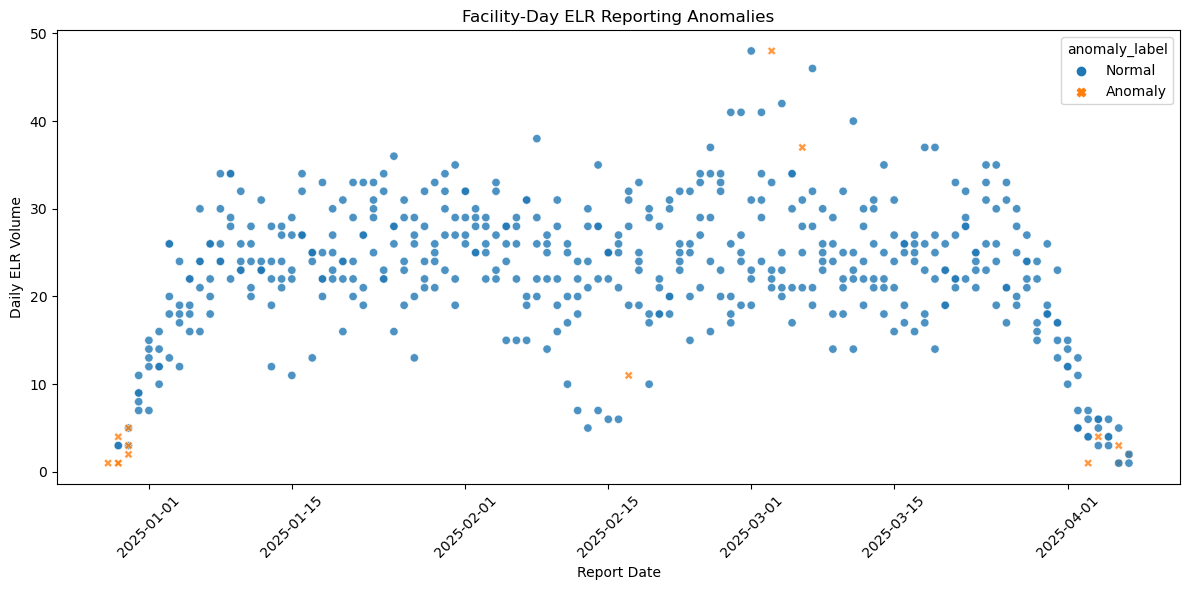

In [24]:
plt.figure(figsize=(12, 6))

sns.scatterplot(
    data=model_data,
    x="report_date",
    y="daily_volume",
    hue="anomaly_label",
    style="anomaly_label",
    alpha=0.8
)

plt.title("Facility-Day ELR Reporting Anomalies")
plt.xlabel("Report Date")
plt.ylabel("Daily ELR Volume")
plt.xticks(rotation=45)
plt.tight_layout()

plt.savefig(output_path / "facility_day_anomalies.png", dpi=150)
plt.show()

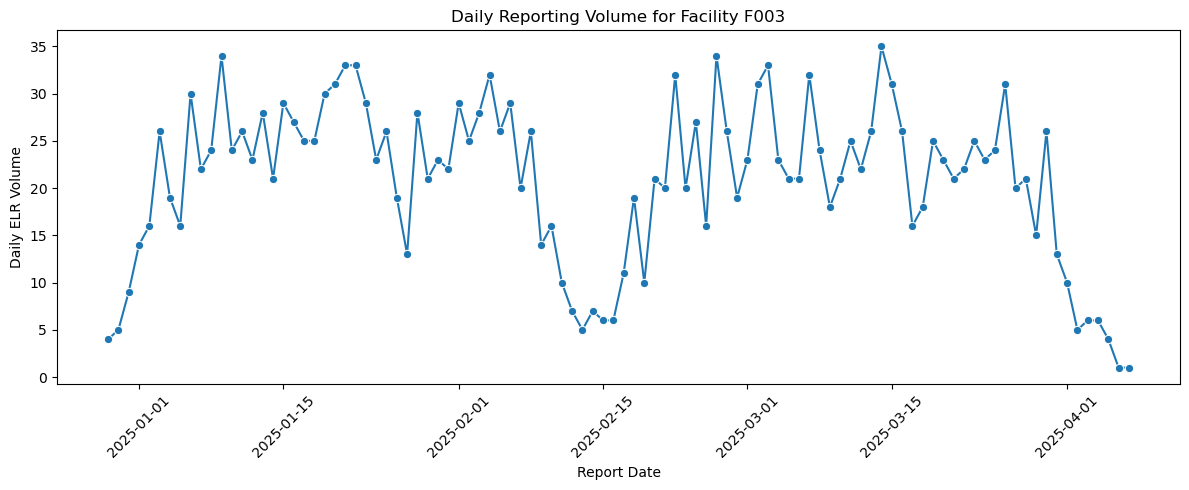

In [25]:
#one facility example
facility_id = "F003"

facility_example = model_data[model_data["facility_id"] == facility_id]

plt.figure(figsize=(12, 5))

sns.lineplot(
    data=facility_example,
    x="report_date",
    y="daily_volume",
    marker="o"
)

plt.title(f"Daily Reporting Volume for Facility {facility_id}")
plt.xlabel("Report Date")
plt.ylabel("Daily ELR Volume")
plt.xticks(rotation=45)
plt.tight_layout()

plt.savefig(output_path / f"{facility_id}_daily_volume.png", dpi=150)
plt.show()

I used Isolation Forest because anomaly labels are usually not available in surveillance operations. The model looks for facility-day reporting patterns that are unusual compared with the overall data.

The features include daily volume, a 7-day rolling average, difference from recent reporting volume, missing demographic/contact percentages, and average reporting delay. These features allow the model to flag possible dropouts, backlog dumps, reporting spikes, delayed reporting, and data quality issues.

 In a real public health workflow, these anomaly flags would help prioritize which facilities or dates need follow-up.